# Banking Analytics — Detailed Exploratory Data Analysis

## Business Challenge

The Czechoslovakia Bank has accumulated large volumes of transactional and customer data over the last five years.
However, the bank lacks a centralized analytical framework to effectively monitor business performance, customer behaviour, 
profitability, loan exposure, and regional market opportunities.

## Analytics Solution Required
Management requires a comprehensive analytics solution integrating customer, account, transaction, card, loan, and
district-level demographic data to generate actionable insights — improving operational efficiency, customer satisfaction,
risk management, and profitability while supporting future product innovation and business growth.


## 1. Import Required Libraries

In [108]:
# Data handling
import pandas as pd
import numpy as np

# SQL Server connection
import pyodbc

# Visualization
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# General settings
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

print("Libraries imported successfully.")


Libraries imported successfully.


## 2. Connect Jupyter Notebook to SQL Server


In [109]:
# SQL Server configuration
SERVER_NAME = r"DESKTOP-L14VCCS\SQLEXPRESS"
DATABASE_NAME = "Banking_Analysis"
DRIVER_NAME = "ODBC Driver 17 for SQL Server"

connection_string = (
    f"DRIVER={{{DRIVER_NAME}}};"
    f"SERVER={SERVER_NAME};"
    f"DATABASE={DATABASE_NAME};"
    "Trusted_Connection=yes;"
)

try:
    conn = pyodbc.connect(connection_string)
    print("Database connection established successfully.")
except pyodbc.Error as error:
    print("Database connection failed.")
    print(error)
    print("\nCheck the server name, database name, ODBC driver, and SQL Server service.")


Database connection established successfully.


### Verify the connection

This query lists the available base tables in the selected database.


In [110]:
table_list_query = '''
SELECT TABLE_NAME
FROM INFORMATION_SCHEMA.TABLES
WHERE TABLE_TYPE = 'BASE TABLE'
ORDER BY TABLE_NAME;
'''

available_tables = pd.read_sql(table_list_query, conn)
available_tables


,TABLE_NAME
0,account_cleaned
1,card_cleaned
2,client_cleaned
3,disp_cleaned
4,district_cleaned
5,loan_cleaned
6,order_cleaned
7,transactions_cleaned


## 3. Import Cleaned SQL Tables

The analysis uses only the cleaned tables created during SQL ETL.


In [111]:
# Mapping between easy Python names and SQL table names
sql_tables = {
    "account": "account_cleaned",
    "card": "card_cleaned",
    "client": "client_cleaned",
    "disposition": "disp_cleaned",
    "district": "district_cleaned",
    "loan": "loan_cleaned",
    "order": "order_cleaned",
    "transaction": "transactions_cleaned"
}

dataframes = {}

for name, sql_table in sql_tables.items():
    query = f"SELECT * FROM [{sql_table}]"
    dataframes[name] = pd.read_sql(query, conn)
    print(f"{sql_table}: {dataframes[name].shape[0]:,} rows, {dataframes[name].shape[1]} columns")

# Create separate variables for convenient use
account_df = dataframes["account"]
card_df = dataframes["card"]
client_df = dataframes["client"]
disp_df = dataframes["disposition"]
district_df = dataframes["district"]
loan_df = dataframes["loan"]
order_df = dataframes["order"]
transactions_df = dataframes["transaction"]


account_cleaned: 4,500 rows, 6 columns
card_cleaned: 892 rows, 4 columns
client_cleaned: 5,369 rows, 9 columns
disp_cleaned: 5,369 rows, 4 columns
district_cleaned: 77 rows, 16 columns
loan_cleaned: 682 rows, 8 columns
order_cleaned: 6,471 rows, 6 columns
transactions_cleaned: 1,048,575 rows, 12 columns


## 4. Dataset Overview

This section checks the size, columns, data types, missing values, and duplicate rows of every table.


In [112]:
# Overall dataset summary
dataset_summary = pd.DataFrame({
    "Table": list(dataframes.keys()),
    "Rows": [df.shape[0] for df in dataframes.values()],
    "Columns": [df.shape[1] for df in dataframes.values()],
    "Missing Cells": [int(df.isna().sum().sum()) for df in dataframes.values()],
    "Duplicate Rows": [int(df.duplicated().sum()) for df in dataframes.values()]
})

dataset_summary


,Table,Rows,Columns,Missing Cells,Duplicate Rows
0,account,4500,6,0,0
1,card,892,4,0,0
2,client,5369,9,0,0
3,disposition,5369,4,0,0
4,district,77,16,2,0
5,loan,682,8,0,0
6,order,6471,6,0,0
7,transaction,1048575,12,1611216,0


## 5. Prepare Date and Numeric Columns

Pandas imported SQL dates as Python objects. They are converted to proper datetime values before time-based analysis.


In [113]:
# Convert available date columns safely
date_columns = {
    "account": ["date"],
    "card": ["issued_cleaned"],
    "client": ["birth_date"],
    "loan": ["date", "loan_date"],
    "transaction": ["Date", "reporting_date"]
}

for table_name, columns in date_columns.items():
    df = dataframes[table_name]
    for column in columns:
        if column in df.columns:
            df[column] = pd.to_datetime(df[column], errors="coerce")

# Convert important numeric fields safely
numeric_columns = {
    "client": ["age"],
    "loan": ["amount", "duration", "payments"],
    "order": ["amount", "amount_cleaned"],
    "transaction": ["amount", "balance", "reporting_year", "transaction_year"]
}

for table_name, columns in numeric_columns.items():
    df = dataframes[table_name]
    for column in columns:
        if column in df.columns:
            df[column] = pd.to_numeric(df[column], errors="coerce")

print("Date and numeric columns prepared successfully.")


Date and numeric columns prepared successfully.


## 6. Reusable Helper Functions

These short helper functions keep the remaining analysis clean and compact.


In [114]:
def missing_report(df):
    """Return missing-value counts and percentages for columns with missing data."""
    report = pd.DataFrame({
        "Missing Values": df.isna().sum(),
        "Missing %": (df.isna().mean() * 100).round(2)
    })
    return report[report["Missing Values"] > 0].sort_values("Missing %", ascending=False)


def value_summary(df, column):
    """Return category counts and percentages."""
    result = df[column].value_counts(dropna=False).reset_index()
    result.columns = [column, "Count"]
    result["Percentage"] = (result["Count"] / len(df) * 100).round(2)
    return result


def plot_bar(data, category, value, title, xlabel="", ylabel="", horizontal=False):
    """Create a simple bar chart."""
    plt.figure(figsize=(6, 4))
    if horizontal:
        plt.barh(data[category].astype(str), data[value])
        plt.xlabel(xlabel)
        plt.ylabel(ylabel)
        plt.gca().invert_yaxis()
    else:
        plt.bar(data[category].astype(str), data[value])
        plt.xlabel(xlabel)
        plt.ylabel(ylabel)
        plt.xticks(rotation=45, ha="right")
    plt.title(title)
    plt.tight_layout()
    plt.show()


def format_millions(value, position):
    return f"{value / 1_000_000:.1f}M"


# Part A — Account EDA


In [115]:
query = "SELECT * FROM [account_cleaned]"
df = pd.read_sql(query, conn)

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
df.head()


Rows: 4,500
Columns: 6


,account_id,district_id,frequency,date,Account_type,Card_Assigned
0,1,18,Monthly Issuance,2020-03-24,NRI Account,Sliver
1,2,1,Monthly Issuance,2018-02-26,Salary Account,Sliver
2,3,5,Monthly Issuance,2022-07-07,NRI Account,Sliver
3,4,12,Monthly Issuance,2021-02-21,Salary Account,Sliver
4,5,15,Monthly Issuance,2022-05-30,Savings Account,Sliver


## Statistical Summary

In [116]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
account_id,"4,500.00",NaN,NaN,NaN,"2,786.07","2,313.81",1.00,"1,182.75","2,368.00","3,552.25","11,382.00"
district_id,"4,500.00",NaN,NaN,NaN,37.31,25.18,1.00,13.00,38.00,60.00,77.00
frequency,4500,3,Monthly Issuance,4167,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date,4500,1535,2018-02-08,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Account_type,4500,3,Savings Account,1533,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Card_Assigned,4500,3,Sliver,4167,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Observation
• Dataset contains 4,500 account records with no missing values.

• Three account types are available, with Savings Account being the most common.

• Monthly Issuance is the dominant statement frequency (4,167 accounts).

• Account opening dates range from 2018 to 2022, indicating five years of customer activity.

• Three card tiers are present, with Silver cards assigned to the majority of accounts.

## Client Growth 

In [117]:
# Account opening year

account_df["Year"] = account_df["date"].dt.year

clients_year = (
    disp_df[disp_df["type"]=="OWNER"]
    .merge(account_df[["account_id","Year"]],on="account_id")
)

growth = (
    clients_year.groupby("Year")["client_id"]
    .nunique()
    .reset_index(name="New Clients")
)

growth

,Year,New Clients
0,2018,1139
1,2019,439
2,2020,661
3,2021,1363
4,2022,898


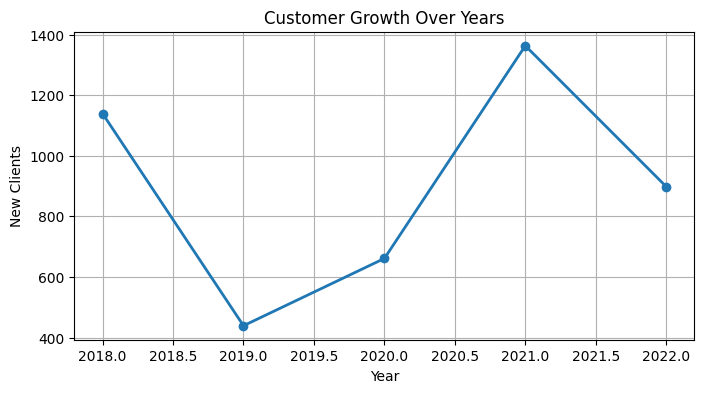

In [118]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

plt.plot(
    growth["Year"],
    growth["New Clients"],
    marker="o",
    linewidth=2
)

plt.title("Customer Growth Over Years")
plt.xlabel("Year")
plt.ylabel("New Clients")

plt.grid(True)

plt.show()

#### Gender Distribution


In [119]:
gender_column = "sex" if "sex" in client_df.columns else "Gender"
gender_summary = value_summary(client_df, gender_column)
gender_summary


,sex,Count,Percentage
0,Male,2724,50.74
1,Female,2645,49.26


#### Age and Customer-Segment Distribution


In [120]:
# Descriptive statistics for customer age
client_df["age"].describe()

count   5,369.00
mean       44.80
std        17.28
min        11.00
25%        30.00
50%        44.00
75%        58.00
max        87.00
Name: age, dtype: float64

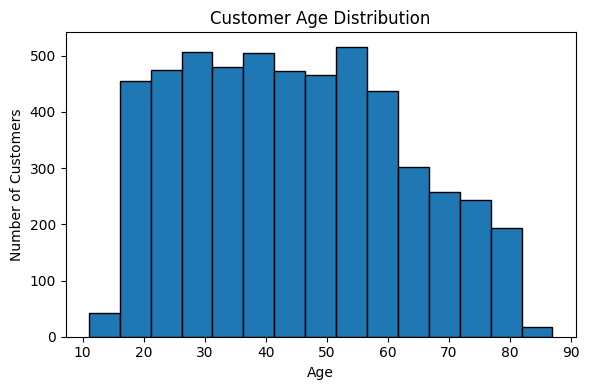

In [121]:
plt.figure(figsize=(6, 4))
plt.hist(client_df["age"].dropna(), bins=15, edgecolor="black")
plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()


,age_group,Count,Percentage
0,46-55,978,18.22
1,26-35,977,18.20
2,36-45,957,17.82
3,18-25,815,15.18
4,56-65,807,15.03
5,66+,763,14.21
6,Below 18,72,1.34


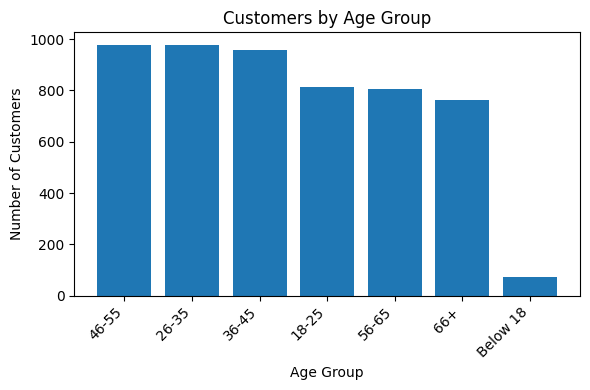

In [122]:
if "age_group" in client_df.columns:
    age_group_summary = value_summary(client_df, "age_group")
    display(age_group_summary)

    plot_bar(
        age_group_summary,
        category="age_group",
        value="Count",
        title="Customers by Age Group",
        xlabel="Age Group",
        ylabel="Number of Customers"
    )


In [123]:
if "customer_category" in client_df.columns:
    category_summary = value_summary(client_df, "customer_category")
    display(category_summary)

if "working_status" in client_df.columns:
    working_summary = value_summary(client_df, "working_status")
    display(working_summary)


,customer_category,Count,Percentage
0,Middle Age,1469,27.36
1,Adult,1439,26.80
2,Young,1310,24.40
3,Senior,1079,20.10
4,Below 18,72,1.34


,working_status,Count,Percentage
0,Working,4218,78.56
1,Retired,1079,20.10
2,Dependent,72,1.34


#### Customers by District and Region


In [124]:
customer_district = (
    client_df
    .merge(
        district_df[["District_Code", "District_Name", "Region"]],
        left_on="district_id",
        right_on="District_Code",
        how="left"
    )
)

top_customer_districts = (
    customer_district
    .groupby("District_Name", dropna=False)["client_id"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
    .reset_index(name="Total Customers")
)

top_customer_districts


,District_Name,Total Customers
0,Hl.m. Praha,663
1,Ostrava - mesto,180
2,Karvina,169
3,Brno - mesto,155
4,Zlin,109
5,Olomouc,104
6,Frydek - Mistek,86
7,Nachod,76
8,Usti nad Orlici,73
9,Kolin,71


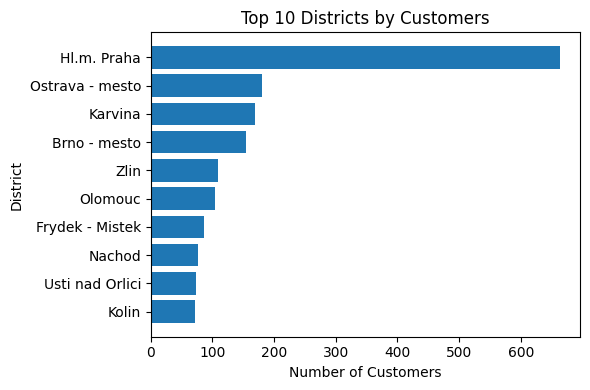

In [125]:
plot_bar(
    top_customer_districts,
    category="District_Name",
    value="Total Customers",
    title="Top 10 Districts by Customers",
    xlabel="Number of Customers",
    ylabel="District",
    horizontal=True
)


In [126]:
region_customer_summary = (
    customer_district
    .groupby("Region", dropna=False)["client_id"]
    .nunique()
    .sort_values(ascending=False)
    .reset_index(name="Total Customers")
)

region_customer_summary


,Region,Total Customers
0,south Moravia,937
1,north Moravia,920
2,central Bohemia,664
3,Prague,663
4,east Bohemia,660
5,north Bohemia,561
6,west Bohemia,515
7,south Bohemia,449


#### Account-Type and Statement-Frequency Analysis


In [127]:
account_type_summary = value_summary(account_df, "Account_type")
frequency_summary = value_summary(account_df, "frequency")

display(account_type_summary)
display(frequency_summary)


,Account_type,Count,Percentage
0,Savings Account,1533,34.07
1,NRI Account,1522,33.82
2,Salary Account,1445,32.11


,frequency,Count,Percentage
0,Monthly Issuance,4167,92.60
1,Weekly Issuance,240,5.33
2,After Transaction,93,2.07


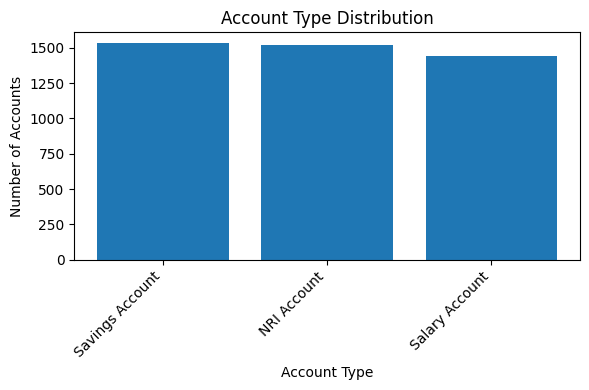

In [128]:
plot_bar(
    account_type_summary,
    category="Account_type",
    value="Count",
    title="Account Type Distribution",
    xlabel="Account Type",
    ylabel="Number of Accounts"
)


#### Owner and User Relationships


In [129]:
relationship_summary = value_summary(disp_df, "type")
relationship_summary


,type,Count,Percentage
0,OWNER,4500,83.81
1,USER,869,16.19


#### Load card_cleaned from SQL Server

In [130]:
query = "SELECT * FROM [card_cleaned]"
df = pd.read_sql(query, conn)

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
df.head()


Rows: 892
Columns: 4


,card_id,disp_id,type,issued_cleaned
0,1,9,Diamond,2021-09-30
1,2,19,Gold,2021-02-28
2,3,41,Diamond,2018-08-31
3,4,42,Gold,2021-10-31
4,5,51,Silver,2018-03-31


#### Data Type and Structure 

In [131]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 892 entries, 0 to 891
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   card_id         892 non-null    int64 
 1   disp_id         892 non-null    int64 
 2   type            892 non-null    object
 3   issued_cleaned  892 non-null    object
dtypes: int64(2), object(2)
memory usage: 28.0+ KB


In [132]:
if "issued_cleaned" in df.columns:
    df["issued_cleaned"] = pd.to_datetime(df["issued_cleaned"], errors="coerce")

print("Date conversion completed.")

Date conversion completed.


In [133]:
missing_report(df)


,Missing Values,Missing %


#### Duplicate Check

In [134]:
print(f"Complete duplicate rows: {df.duplicated().sum():,}")
duplicate_keys = (
    df.groupby("card_id")
      .size()
      .reset_index(name="Duplicate_Count")
)

duplicate_keys = duplicate_keys[
    duplicate_keys["Duplicate_Count"] > 1
]

print(f"Duplicate card_id values: {len(duplicate_keys):,}")
duplicate_keys.head()


Complete duplicate rows: 0
Duplicate card_id values: 0


,card_id,Duplicate_Count


#### Statistical Summary

In [135]:
df.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
card_id,892.00,NaN,NaN,NaN,480.86,1.00,229.75,456.50,684.25,"1,247.00",306.93
disp_id,892.00,NaN,NaN,NaN,"3,511.86",9.00,"1,387.00","2,938.50","4,459.50","13,660.00","2,984.37"
type,892,3,Gold,659,NaN,NaN,NaN,NaN,NaN,NaN,NaN
issued_cleaned,892,NaN,NaN,NaN,2020-09-03 02:44:39.820627712,2016-10-31 00:00:00,2019-12-31 00:00:00,2020-12-31 00:00:00,2021-07-31 00:00:00,2021-11-30 00:00:00,NaN


#### Categorical Analysis

## KPI's

In [160]:
card_kpis = pd.Series({
    "Total Cards": df["card_id"].nunique(),
    "Earliest Issue Date": df["issued_cleaned"].min(),
    "Latest Issue Date": df["issued_cleaned"].max()
})

card_kpis

Total Cards                            892
Earliest Issue Date    2016-10-31 00:00:00
Latest Issue Date      2021-11-30 00:00:00
dtype: object

#### Card Issuance Trend

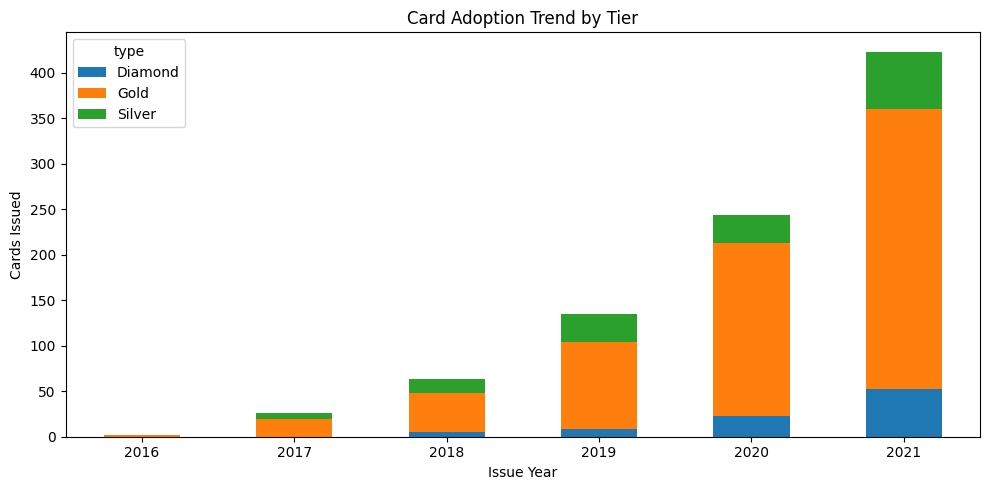

In [161]:
df["Issued_Year"] = df["issued_cleaned"].dt.year

card_trend = (
    df.groupby(["Issued_Year", "type"])
      .size()
      .reset_index(name="Cards_Issued")
)

card_trend.head()

card_trend_pivot = card_trend.pivot(
    index="Issued_Year",
    columns="type",
    values="Cards_Issued"
).fillna(0)

card_trend_pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 5)
)

plt.title("Card Adoption Trend by Tier")
plt.xlabel("Issue Year")
plt.ylabel("Cards Issued")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [162]:
# Latest balance of each account
latest_bal = (transactions_df.sort_values("reporting_date")
              .groupby("account_id")
              .tail(1)[["account_id", "balance"]])

# Account count and average balance by type
q1 = (account_df.merge(latest_bal, on="account_id", how="left")
      .groupby("Account_type")
      .agg(Account_Count=("account_id", "nunique"),
           Avg_Balance=("balance", "mean"))
      .round(2)
      .reset_index())

display(q1)

,Account_type,Account_Count,Avg_Balance
0,NRI Account,1522,"33,825.19"
1,Salary Account,1445,"33,028.25"
2,Savings Account,1533,"32,726.40"


#### Card Type Trend

In [163]:
# Extract issue year
card_df["Year"] = card_df["issued_cleaned"].dt.year

# Card type distribution by year
q2 = (card_df.groupby(["Year", "type"])
      .size()
      .reset_index(name="Count"))

display(q2)

,Year,type,Count
0,2016,Gold,2
1,2017,Gold,20
2,2017,Silver,6
3,2018,Diamond,5
4,2018,Gold,43
5,2018,Silver,15
6,2019,Diamond,8
7,2019,Gold,96
8,2019,Silver,31
9,2020,Diamond,23


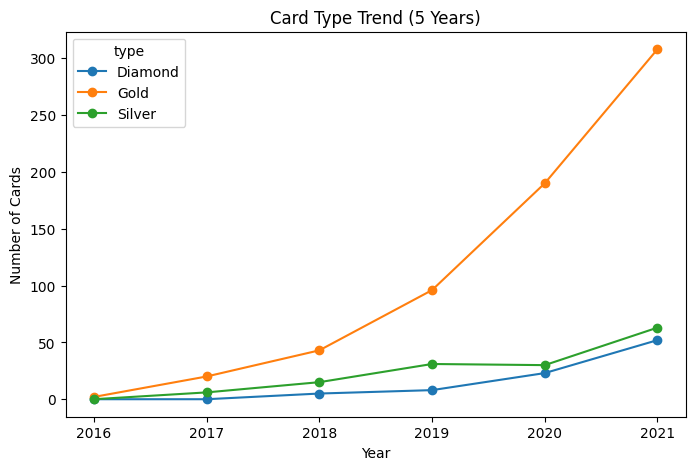

In [164]:
q2.pivot(index="Year", columns="type", values="Count").fillna(0).plot(
    kind="line",
    marker="o",
    figsize=(8,5)
)

plt.title("Card Type Trend (5 Years)")
plt.ylabel("Number of Cards")
plt.show()

#### Card Penetration Rate

In [165]:
# Total dispositions
total_disp = disp_df["disp_id"].nunique()

# Dispositions having a card
card_disp = card_df["disp_id"].nunique()

# Card penetration rate
penetration = round((card_disp / total_disp) * 100, 2)

print("Total Dispositions :", total_disp)
print("Dispositions with Card :", card_disp)
print("Card Penetration Rate :", penetration, "%")

Total Dispositions : 5369
Dispositions with Card : 892
Card Penetration Rate : 16.61 %


In [166]:
# Overall frequency distribution
q4 = (account_df["frequency"]
      .value_counts()
      .reset_index())

q4.columns = ["Frequency", "Count"]

display(q4)

q4_type = pd.crosstab(
    account_df["Account_type"],
    account_df["frequency"]
)

display(q4_type)

,Frequency,Count
0,Monthly Issuance,4167
1,Weekly Issuance,240
2,After Transaction,93


frequency,After Transaction,Monthly Issuance,Weekly Issuance
Account_type,,,
NRI Account,34,1398,90
Salary Account,33,1332,80
Savings Account,26,1437,70


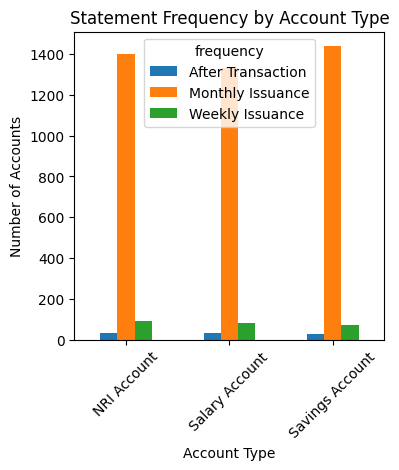

In [168]:
q4_type.plot(kind="bar", figsize=(4,4))

plt.title("Statement Frequency by Account Type")
plt.xlabel("Account Type")
plt.ylabel("Number of Accounts")
plt.xticks(rotation=45)
plt.show()

In [169]:
# Merge account and card tables through disposition
q5 = (disp_df.merge(account_df[["account_id", "date"]], on="account_id")
            .merge(card_df[["disp_id", "issued_cleaned"]], on="disp_id"))

# Calculate days taken to issue the first card
q5["Days_To_Card"] = (q5["issued_cleaned"] - q5["date"]).dt.days

print("Average Days:", round(q5["Days_To_Card"].mean(), 2))

Average Days: 31.09


In [170]:
q5["Days_To_Card"].describe()

count     892.00
mean       31.09
std       464.36
min      -559.00
25%      -346.50
50%       -87.50
75%       287.00
max     1,409.00
Name: Days_To_Card, dtype: float64

# Part B — Transaction and Financial EDA


#### Transaction KPIs


In [171]:
transaction_kpis = pd.Series({
    "Total Transactions": transactions_df["trans_id"].nunique(),
    "Total Transaction Amount": transactions_df["amount"].sum(),
    "Average Transaction Amount": transactions_df["amount"].mean(),
    "Median Transaction Amount": transactions_df["amount"].median(),
    "Maximum Transaction Amount": transactions_df["amount"].max(),
    "Average Balance": transactions_df["balance"].mean()
})

transaction_kpis


Total Transactions               1,048,575.00
Total Transaction Amount     6,230,793,381.00
Average Transaction Amount           5,942.15
Median Transaction Amount            2,100.00
Maximum Transaction Amount          87,400.00
Average Balance                     38,456.73
dtype: float64

#### Credit vs Withdrawal Analysis


In [172]:
type_summary = (
    transactions_df
    .groupby("Type")
    .agg(
        Transaction_Count=("trans_id", "count"),
        Total_Amount=("amount", "sum"),
        Average_Amount=("amount", "mean"),
        Average_Balance=("balance", "mean")
    )
    .reset_index()
)

type_summary


,Type,Transaction_Count,Total_Amount,Average_Amount,Average_Balance
0,Credit,400209,3216335973,"8,036.64","41,381.37"
1,Withdrawal,648366,3014457408,"4,649.31","36,651.47"


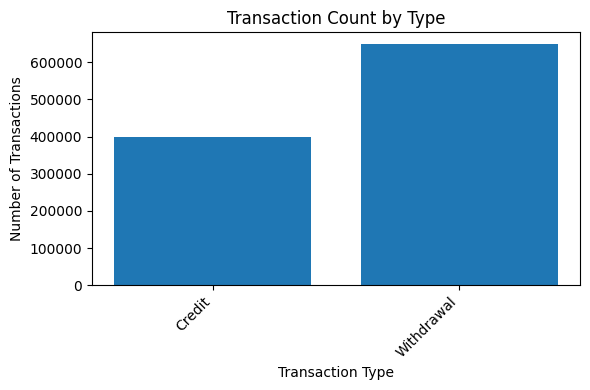

In [173]:
plot_bar(
    type_summary,
    category="Type",
    value="Transaction_Count",
    title="Transaction Count by Type",
    xlabel="Transaction Type",
    ylabel="Number of Transactions"
)


#### Transaction Trend by Reporting Year


In [174]:
year_column = "reporting_year" if "reporting_year" in transactions_df.columns else "transaction_year"

yearly_transaction_summary = (
    transactions_df
    .groupby(year_column)
    .agg(
        Transaction_Count=("trans_id", "count"),
        Transaction_Value=("amount", "sum"),
        Average_Amount=("amount", "mean")
    )
    .reset_index()
    .sort_values(year_column)
)

yearly_transaction_summary


,reporting_year,Transaction_Count,Transaction_Value,Average_Amount
0,2017,314532,1867735412,"5,938.14"
1,2018,284409,1688347890,"5,936.34"
2,2019,196779,1163864249,"5,914.58"
3,2020,133022,767739197,"5,771.52"
4,2021,91628,538796646,"5,880.26"
5,2022,28205,204309987,"7,243.75"


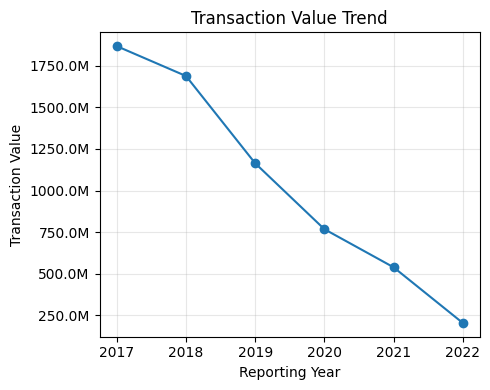

In [178]:
plt.figure(figsize=(5, 4))
plt.plot(
    yearly_transaction_summary[year_column],
    yearly_transaction_summary["Transaction_Value"],
    marker="o"
)
plt.title("Transaction Value Trend")
plt.xlabel("Reporting Year")
plt.ylabel("Transaction Value")
plt.gca().yaxis.set_major_formatter(FuncFormatter(format_millions))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


#### Monthly Seasonality


In [179]:
transaction_date_column = "reporting_date" if "reporting_date" in transactions_df.columns else "Date"

transactions_df["Month_Number"] = transactions_df[transaction_date_column].dt.month
transactions_df["Month_Name"] = transactions_df[transaction_date_column].dt.month_name().str[:3]

monthly_transaction_summary = (
    transactions_df
    .groupby(["Month_Number", "Month_Name"])
    .agg(
        Transaction_Count=("trans_id", "count"),
        Transaction_Value=("amount", "sum")
    )
    .reset_index()
    .sort_values("Month_Number")
)

monthly_transaction_summary


,Month_Number,Month_Name,Transaction_Count,Transaction_Value
0,1,Jan,122214,544557770
1,2,Feb,65824,379258562
2,3,Mar,79922,443680377
3,4,Apr,76954,449588670
4,5,May,79931,478851976
5,6,Jun,88276,668731716
6,7,Jul,83791,491014765
7,8,Aug,86204,509012459
8,9,Sep,87955,522560466
9,10,Oct,90839,542451936


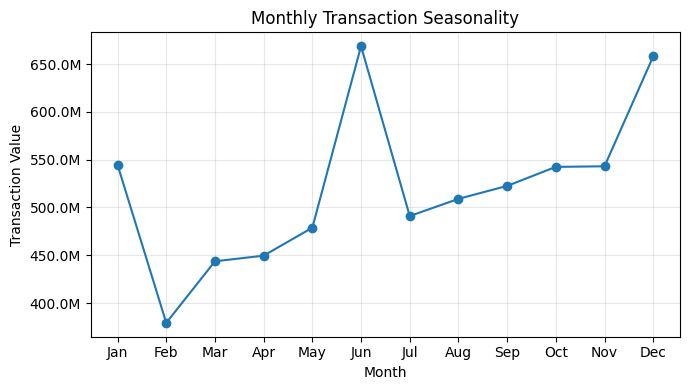

In [181]:
plt.figure(figsize=(7, 4))
plt.plot(
    monthly_transaction_summary["Month_Name"],
    monthly_transaction_summary["Transaction_Value"],
    marker="o"
)
plt.title("Monthly Transaction Seasonality")
plt.xlabel("Month")
plt.ylabel("Transaction Value")
plt.gca().yaxis.set_major_formatter(FuncFormatter(format_millions))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


#### Operation and Purpose Analysis


In [182]:
operation_summary = (
    transactions_df
    .groupby("operation", dropna=False)
    .agg(
        Transaction_Count=("trans_id", "count"),
        Total_Amount=("amount", "sum")
    )
    .sort_values("Total_Amount", ascending=False)
    .reset_index()
)

operation_summary


,operation,Transaction_Count,Total_Amount
0,Credit in cash,156320,2408179630
1,Withdrawal in cash,432377,2324392424
2,Electronic funds transfer,65226,781479953
3,Remittance to Another Bank,208283,672638484
4,Interest Credit,178663,26676390
5,Credit card withdrawal,7706,17426500


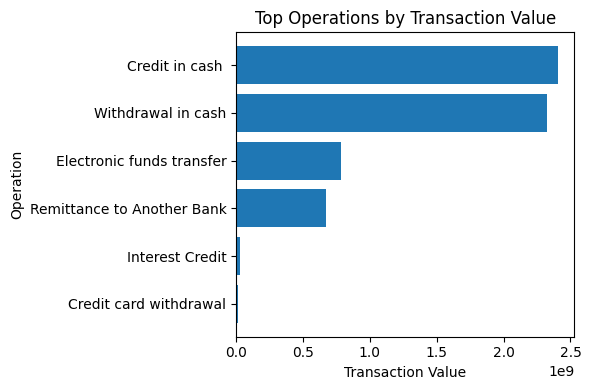

In [183]:
plot_bar(
    operation_summary.head(10),
    category="operation",
    value="Total_Amount",
    title="Top Operations by Transaction Value",
    xlabel="Transaction Value",
    ylabel="Operation",
    horizontal=True
)


In [184]:
purpose_summary = (
    transactions_df
    .dropna(subset=["Purpose"])
    .groupby("Purpose")
    .agg(
        Transaction_Count=("trans_id", "count"),
        Total_Amount=("amount", "sum")
    )
    .sort_values("Total_Amount", ascending=False)
    .reset_index()
)

purpose_summary


,Purpose,Transaction_Count,Total_Amount
0,Household,118057,498450616
1,Old-age Pension,30338,167472118
2,Loan Payment,13580,55253001
3,Interest Credited,178663,26676390
4,Insurance Payment,18500,24175193
5,Payment on Statement,155832,2744045
6,Sanction Interest,1527,35817


#### Balance Distribution and Outlier Review


In [185]:
transactions_df[["amount", "balance"]].describe(percentiles=[0.01, 0.25, 0.50, 0.75, 0.95, 0.99])


,amount,balance
count,"1,048,575.00","1,048,575.00"
mean,"5,942.15","38,456.73"
std,"9,529.36","22,068.51"
min,0.00,"-41,125.70"
1%,15.00,"3,468.50"
25%,136.00,"22,388.40"
50%,"2,100.00","33,098.80"
75%,"6,817.00","49,502.20"
95%,"25,756.00","82,467.93"
99%,"45,463.00","108,219.51"


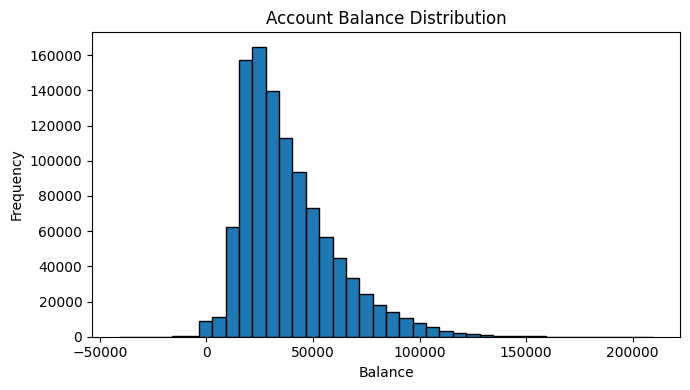

In [186]:
plt.figure(figsize=(7, 4))
plt.hist(transactions_df["balance"].dropna(), bins=40, edgecolor="black")
plt.title("Account Balance Distribution")
plt.xlabel("Balance")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


In [187]:
# IQR-based amount outlier detection
q1 = transactions_df["amount"].quantile(0.25)
q3 = transactions_df["amount"].quantile(0.75)
iqr = q3 - q1

lower_limit = q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr

transaction_outliers = transactions_df[
    (transactions_df["amount"] < lower_limit) |
    (transactions_df["amount"] > upper_limit)
]

print(f"Lower limit: {lower_limit:,.2f}")
print(f"Upper limit: {upper_limit:,.2f}")
print(f"Potential amount outliers: {len(transaction_outliers):,}")


Lower limit: -9,885.50
Upper limit: 16,838.50
Potential amount outliers: 119,182


#### Missing Transaction Fields by Operation


In [188]:
nullable_transaction_columns = [
    column for column in ["Purpose", "bank", "account_partern_id"]
    if column in transactions_df.columns
]

for column in nullable_transaction_columns:
    print(f"\nMissing {column} values by operation:")
    display(
        transactions_df[transactions_df[column].isna()]
        .groupby("operation")
        .size()
        .sort_values(ascending=False)
        .reset_index(name=f"Missing {column}")
    )



Missing Purpose values by operation:


,operation,Missing Purpose
0,Withdrawal in cash,272192
1,Credit in cash,156320
2,Remittance to Another Bank,60972
3,Electronic funds transfer,34888
4,Credit card withdrawal,7706



Missing bank values by operation:


,operation,Missing bank
0,Withdrawal in cash,183861
1,Interest Credit,73081
2,Credit in cash,64074
3,Credit card withdrawal,4549



Missing account_partern_id values by operation:


,operation,Missing account_partern_id
0,Withdrawal in cash,418589
1,Interest Credit,178663
2,Credit in cash,156320
3,Remittance to Another Bank,1


# Part C — Product and Card Adoption EDA


#### Product-Adoption KPIs


In [189]:
total_accounts = account_df["account_id"].nunique()
total_cards = card_df["card_id"].nunique()
total_loans = loan_df["loan_id"].nunique()
accounts_with_cards = disp_df.merge(card_df, on="disp_id", how="inner")["account_id"].nunique()
accounts_with_loans = loan_df["account_id"].nunique()

product_kpis = pd.Series({
    "Total Accounts": total_accounts,
    "Total Cards": total_cards,
    "Total Loans": total_loans,
    "Card Penetration %": accounts_with_cards / total_accounts * 100,
    "Loan Penetration %": accounts_with_loans / total_accounts * 100
})

product_kpis


Total Accounts       4,500.00
Total Cards            892.00
Total Loans            682.00
Card Penetration %      19.82
Loan Penetration %      15.16
dtype: float64

#### Card-Type Distribution


In [190]:
card_type_summary = value_summary(card_df, "type")
card_type_summary


,type,Count,Percentage
0,Gold,659,73.88
1,Silver,145,16.26
2,Diamond,88,9.87


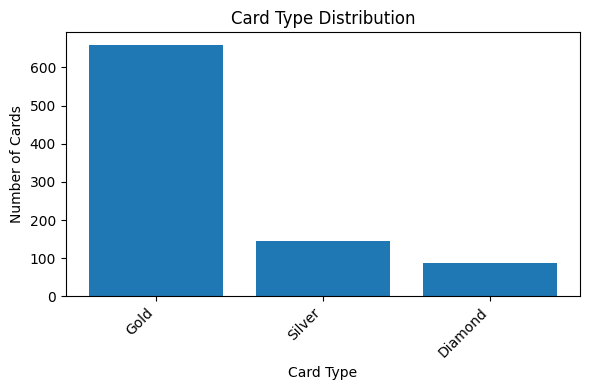

In [191]:
plot_bar(
    card_type_summary,
    category="type",
    value="Count",
    title="Card Type Distribution",
    xlabel="Card Type",
    ylabel="Number of Cards"
)


#### Card Adoption Trend by Tier


In [157]:
card_df["Issued_Year"] = card_df["issued_cleaned"].dt.year

card_trend = (
    card_df
    .groupby(["Issued_Year", "type"])
    .size()
    .reset_index(name="Cards Issued")
)

card_trend.head()


,Issued_Year,type,Cards Issued
0,2016,Gold,2
1,2017,Gold,20
2,2017,Silver,6
3,2018,Diamond,5
4,2018,Gold,43


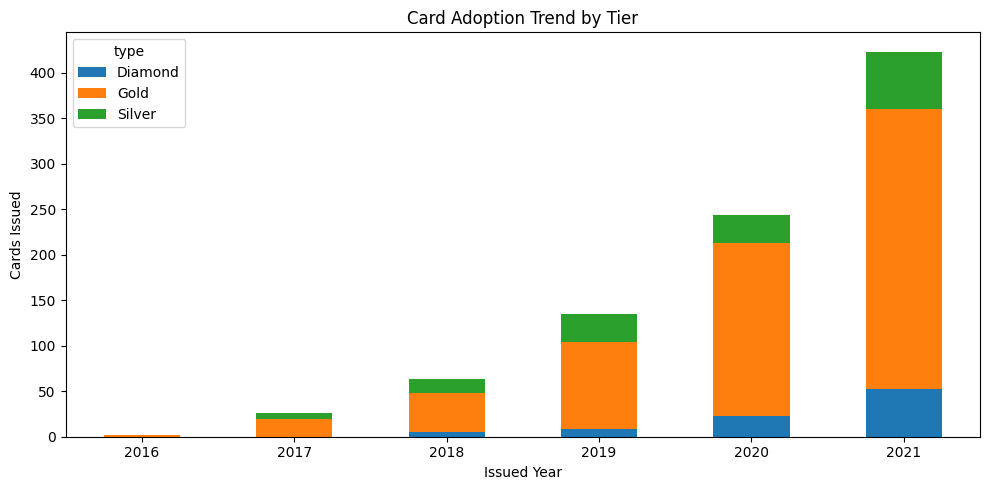

In [80]:
card_trend_pivot = card_trend.pivot(
    index="Issued_Year",
    columns="type",
    values="Cards Issued"
).fillna(0)

card_trend_pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 5)
)

plt.title("Card Adoption Trend by Tier")
plt.xlabel("Issued Year")
plt.ylabel("Cards Issued")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


#### Card Type by Account Type


In [81]:
card_account = (
    card_df
    .merge(disp_df[["disp_id", "account_id"]], on="disp_id", how="left")
    .merge(account_df[["account_id", "Account_type"]], on="account_id", how="left")
)

card_account_summary = (
    card_account
    .groupby(["Account_type", "type"])
    .size()
    .reset_index(name="Card Count")
)

card_account_summary


,Account_type,type,Card Count
0,NRI Account,Diamond,30
1,NRI Account,Gold,237
2,NRI Account,Silver,50
3,Salary Account,Diamond,30
4,Salary Account,Gold,201
5,Salary Account,Silver,42
6,Savings Account,Diamond,28
7,Savings Account,Gold,221
8,Savings Account,Silver,53


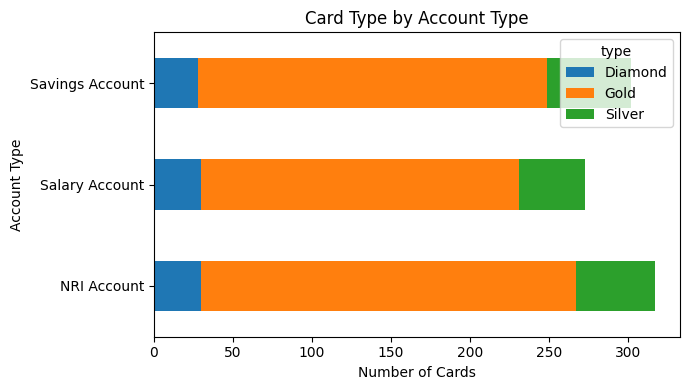

In [201]:
card_account_pivot = card_account_summary.pivot(
    index="Account_type",
    columns="type",
    values="Card Count"
).fillna(0)

card_account_pivot.plot(
    kind="barh",
    stacked=True,
    figsize=(7, 4)
)

plt.title("Card Type by Account Type")
plt.xlabel("Number of Cards")
plt.ylabel("Account Type")
plt.tight_layout()
plt.show()


#### Card Adoption by Customer Segment


In [202]:
card_customer = (
    card_df
    .merge(disp_df[["disp_id", "client_id"]], on="disp_id", how="left")
    .merge(
        client_df[["client_id", "customer_category", "age_group", gender_column]],
        on="client_id",
        how="left"
    )
)

segment_card_summary = (
    card_customer
    .groupby(["customer_category", "type"])
    .size()
    .reset_index(name="Card Count")
)

segment_card_summary


,customer_category,type,Card Count
0,Adult,Diamond,30
1,Adult,Gold,217
2,Below 18,Silver,20
3,Middle Age,Diamond,34
4,Middle Age,Gold,263
5,Senior,Diamond,8
6,Senior,Gold,37
7,Young,Diamond,16
8,Young,Gold,142
9,Young,Silver,125


# Part D — Loan Portfolio and Credit Risk EDA


#### Loan Portfolio KPIs


In [203]:
loan_kpis = pd.Series({
    "Total Loans": loan_df["loan_id"].nunique(),
    "Total Loan Amount": loan_df["amount"].sum(),
    "Average Loan Amount": loan_df["amount"].mean(),
    "Average Monthly Payment": loan_df["payments"].mean(),
    "Average Duration": loan_df["duration"].mean(),
    "Clients in Debt": (loan_df["loan_status"] == "Client in Debt").sum(),
    "Loan Not Paid": (loan_df["loan_status"] == "Loan Not Paid").sum(),
    "Running Contracts": (loan_df["loan_status"] == "Running Contract").sum()
})

loan_kpis


Total Loans                       682.00
Total Loan Amount         103,261,740.00
Average Loan Amount           151,410.18
Average Monthly Payment         4,190.66
Average Duration                   36.49
Clients in Debt                    45.00
Loan Not Paid                      31.00
Running Contracts                 403.00
dtype: float64

#### Loan-Status Distribution


In [85]:
loan_status_summary = value_summary(loan_df, "loan_status")
loan_status_summary


,loan_status,Count,Percentage
0,Running Contract,403,59.09
1,Contract Finished,203,29.77
2,Client in Debt,45,6.60
3,Loan Not Paid,31,4.55


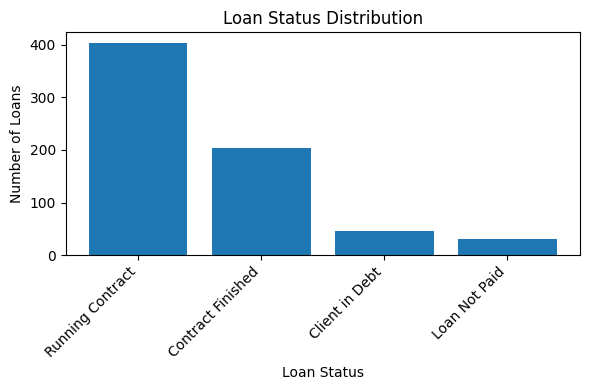

In [86]:
plot_bar(
    loan_status_summary,
    category="loan_status",
    value="Count",
    title="Loan Status Distribution",
    xlabel="Loan Status",
    ylabel="Number of Loans"
)


#### Loan Amount Trend


In [87]:
loan_date_column = "loan_date" if "loan_date" in loan_df.columns else "date"
loan_df["Loan_Year"] = loan_df[loan_date_column].dt.year

loan_year_summary = (
    loan_df
    .groupby("Loan_Year")
    .agg(
        Loan_Count=("loan_id", "count"),
        Loan_Amount=("amount", "sum")
    )
    .reset_index()
    .sort_values("Loan_Year")
)

loan_year_summary


,Loan_Year,Loan_Count,Loan_Amount
0,2016,20,2619276
1,2017,101,13379904
2,2018,90,13344372
3,2019,117,18317676
4,2020,196,30731364
5,2021,158,24869148


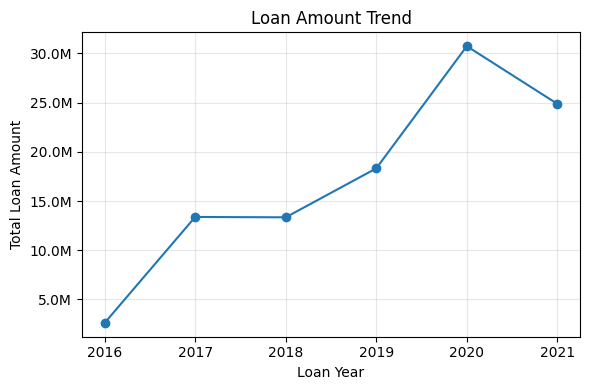

In [205]:
plt.figure(figsize=(6, 4))
plt.plot(loan_year_summary["Loan_Year"], loan_year_summary["Loan_Amount"], marker="o")
plt.title("Loan Amount Trend")
plt.xlabel("Loan Year")
plt.ylabel("Total Loan Amount")
plt.gca().yaxis.set_major_formatter(FuncFormatter(format_millions))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


#### Loan Status by Duration


In [206]:
loan_duration_status = pd.crosstab(
    loan_df["duration"],
    loan_df["loan_status"],
    normalize="index"
) * 100

loan_duration_status.round(2)


loan_status,Client in Debt,Contract Finished,Loan Not Paid,Running Contract
duration,,,,
12,0.76,70.99,7.63,20.61
24,4.35,46.38,7.97,41.30
36,6.15,24.62,5.38,63.85
48,10.14,7.97,1.45,80.43
60,11.03,2.07,0.69,86.21


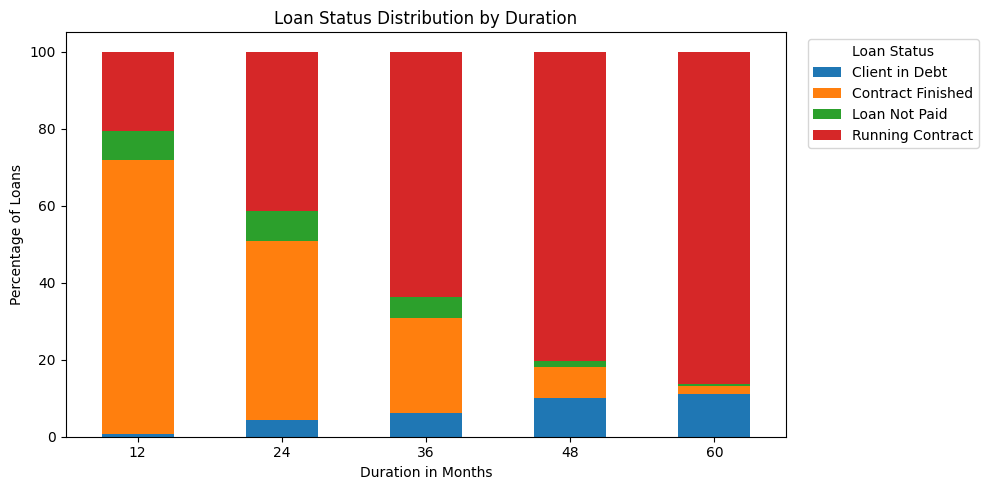

In [207]:
loan_duration_status.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 5)
)

plt.title("Loan Status Distribution by Duration")
plt.xlabel("Duration in Months")
plt.ylabel("Percentage of Loans")
plt.legend(title="Loan Status", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


#### Loan Reconciliation Check

The expected relationship is approximately:

`Loan Amount ≈ Monthly Payment × Duration`


In [208]:
loan_df["Calculated_Amount"] = loan_df["payments"] * loan_df["duration"]
loan_df["Amount_Difference"] = loan_df["amount"] - loan_df["Calculated_Amount"]

loan_df[
    ["loan_id", "amount", "payments", "duration", "Calculated_Amount", "Amount_Difference"]
].head(10)


,loan_id,amount,payments,duration,Calculated_Amount,Amount_Difference
0,4959,80952,"3,373.00",24,"80,952.00",0.00
1,4961,30276,"2,523.00",12,"30,276.00",0.00
2,4962,30276,"2,523.00",12,"30,276.00",0.00
3,4967,318480,"5,308.00",60,"318,480.00",0.00
4,4968,110736,"2,307.00",48,"110,736.00",0.00
5,4973,165960,"6,915.00",24,"165,960.00",0.00
6,4986,102876,"8,573.00",12,"102,876.00",0.00
7,4988,265320,"7,370.00",36,"265,320.00",0.00
8,4989,352704,"7,348.00",48,"352,704.00",0.00
9,4990,162576,"4,516.00",36,"162,576.00",0.00


In [209]:
loan_df["Amount_Difference"].describe()


count   682.00
mean      0.00
std       0.00
min       0.00
25%       0.00
50%       0.00
75%       0.00
max       0.00
Name: Amount_Difference, dtype: float64

#### Loan Exposure by District


In [210]:
loan_district = (
    loan_df
    .merge(account_df[["account_id", "district_id"]], on="account_id", how="left")
    .merge(
        district_df[["District_Code", "District_Name", "Region"]],
        left_on="district_id",
        right_on="District_Code",
        how="left"
    )
)

top_loan_districts = (
    loan_district
    .groupby("District_Name")["amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index(name="Total Loan Amount")
)

top_loan_districts


,District_Name,Total Loan Amount
0,Hl.m. Praha,12932412
1,Brno - mesto,4049400
2,Ostrava - mesto,3260220
3,Karvina,3059820
4,Zlin,3012768
5,Prachatice,2356692
6,Olomouc,2287596
7,Usti nad Orlici,2213160
8,Svitavy,2100084
9,Kutna Hora,2095980


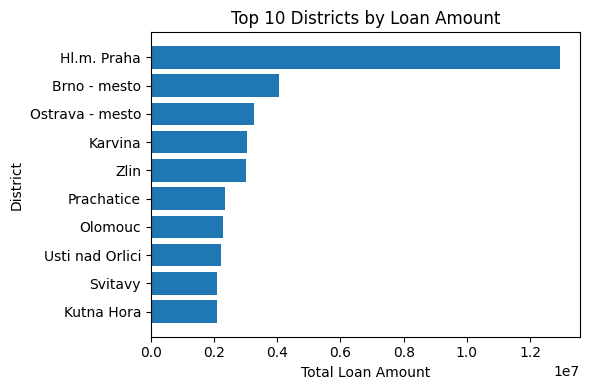

In [94]:
plot_bar(
    top_loan_districts,
    category="District_Name",
    value="Total Loan Amount",
    title="Top 10 Districts by Loan Amount",
    xlabel="Total Loan Amount",
    ylabel="District",
    horizontal=True
)


#### Loan Risk by Customer Segment


In [211]:
loan_customer = (
    loan_df
    .merge(disp_df[["account_id", "client_id", "type"]], on="account_id", how="left")
)

# Keep account owners to avoid duplicating a loan for additional users
loan_customer = loan_customer[loan_customer["type"].str.upper() == "OWNER"]

loan_customer = loan_customer.merge(
    client_df[["client_id", "age_group", "customer_category", gender_column]],
    on="client_id",
    how="left"
)

loan_segment_risk = (
    loan_customer
    .groupby(["customer_category", "loan_status"])
    .size()
    .reset_index(name="Loan Count")
)

loan_segment_risk


,customer_category,loan_status,Loan Count
0,Adult,Client in Debt,16
1,Adult,Contract Finished,70
2,Adult,Loan Not Paid,8
3,Adult,Running Contract,145
4,Middle Age,Client in Debt,14
5,Middle Age,Contract Finished,66
6,Middle Age,Loan Not Paid,14
7,Middle Age,Running Contract,135
8,Senior,Client in Debt,1
9,Senior,Contract Finished,8


# Part E — Order and Transfer EDA


#### Order KPIs and Amount Distribution


In [212]:
order_amount_column = "amount_cleaned" if "amount_cleaned" in order_df.columns else "amount"

order_kpis = pd.Series({
    "Total Orders": order_df["order_id"].nunique(),
    "Total Order Amount": order_df[order_amount_column].sum(),
    "Average Order Amount": order_df[order_amount_column].mean(),
    "Minimum Order Amount": order_df[order_amount_column].min(),
    "Maximum Order Amount": order_df[order_amount_column].max(),
    "Destination Banks": order_df["Bank_to"].nunique()
})

order_kpis


Total Orders                6,471.00
Total Order Amount     21,228,993.60
Average Order Amount        3,280.64
Minimum Order Amount            1.00
Maximum Order Amount       14,882.00
Destination Banks              13.00
dtype: float64

#### Top Destination Banks


In [214]:
order_bank_summary = (
    order_df
    .groupby("Bank_to")
    .agg(
        Order_Count=("order_id", "count"),
        Total_Amount=(order_amount_column, "sum"),
        Average_Amount=(order_amount_column, "mean")
    )
    .sort_values("Total_Amount", ascending=False)
    .reset_index()
)

order_bank_summary.head(10)


,Bank_to,Order_Count,Total_Amount,Average_Amount
0,Hypotecni bank,515,"1,730,775.70","3,360.73"
1,Fio bank,531,"1,728,170.30","3,254.56"
2,Kameron bank,519,"1,707,389.50","3,289.77"
3,Trinity Bank,483,"1,698,275.00","3,516.10"
4,Bank Creditas,511,"1,690,662.70","3,308.54"
5,Raiffeisen bank,500,"1,685,397.00","3,370.79"
6,Max bank,499,"1,675,704.20","3,358.12"
7,Air Bank,521,"1,636,982.80","3,142.00"
8,PPF Bank,496,"1,626,195.40","3,278.62"
9,Moneta Money Bank,487,"1,603,264.80","3,292.12"


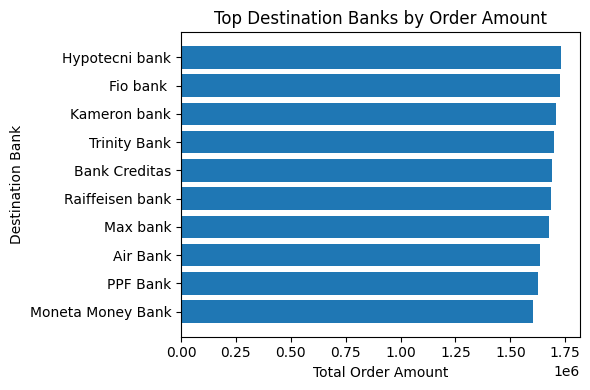

In [215]:
plot_bar(
    order_bank_summary.head(10),
    category="Bank_to",
    value="Total_Amount",
    title="Top Destination Banks by Order Amount",
    xlabel="Total Order Amount",
    ylabel="Destination Bank",
    horizontal=True
)


# Part F — Regional and Economic Analysis


#### District Economic Indicators


In [221]:
economic_columns = [
    "Population",
    "Average_Salary",
    "Unemployment_Rate_1995",
    "Unemployment_Rate_1996",
    "Crimes_1995",
    "Crimes_1996"
]

available_economic_columns = [
    column for column in economic_columns
    if column in district_df.columns
]

district_df[available_economic_columns].describe()


,Population,Average_Salary
count,77.00,77.00
mean,"133,884.90","9,031.68"
std,"136,913.46",790.20
min,"42,821.00","8,110.00"
25%,"85,852.00","8,512.00"
50%,"108,871.00","8,814.00"
75%,"139,012.00","9,317.00"
max,"1,204,953.00","12,541.00"


#### Customers, Transactions, and Loans by Region


In [222]:
# Customers by region
customers_by_region = (
    customer_district
    .groupby("Region")["client_id"]
    .nunique()
    .reset_index(name="Customers")
)

# Transactions by region
transaction_region = (
    transactions_df
    .merge(account_df[["account_id", "district_id"]], on="account_id", how="left")
    .merge(
        district_df[["District_Code", "Region"]],
        left_on="district_id",
        right_on="District_Code",
        how="left"
    )
    .groupby("Region")["amount"]
    .sum()
    .reset_index(name="Transaction Amount")
)

# Loans by region
loans_by_region = (
    loan_district
    .groupby("Region")["amount"]
    .sum()
    .reset_index(name="Loan Amount")
)

regional_summary = (
    customers_by_region
    .merge(transaction_region, on="Region", how="outer")
    .merge(loans_by_region, on="Region", how="outer")
)

regional_summary.sort_values("Transaction Amount", ascending=False)


,Region,Customers,Transaction Amount,Loan Amount
4,north Moravia,920,1133458257,18081312
6,south Moravia,937,1053663616,19678848
1,central Bohemia,664,810501162,13985304
0,Prague,663,801309185,12932412
2,east Bohemia,660,718945396,13943724
3,north Bohemia,561,618806982,7486620
7,west Bohemia,515,576450010,7779384
5,south Bohemia,449,517658773,9374136


## Part G - Operational Efficiency 

In [225]:
# Classify transactions into Cash and Digital
transactions_df["Transaction_Mode"] = transactions_df["operation"].apply(
    lambda x: "Cash" if "cash" in str(x).lower() else "Digital/Bank Transfer"
)

# Calculate count and percentage
q2 = (transactions_df["Transaction_Mode"]
      .value_counts()
      .reset_index())

q2.columns = ["Transaction_Mode", "Count"]

q2["Percentage"] = (
    q2["Count"] / q2["Count"].sum() * 100
).round(2)

display(q2)

,Transaction_Mode,Count,Percentage
0,Cash,588697,56.14
1,Digital/Bank Transfer,459878,43.86


In [226]:
q3 = (transactions_df
      .groupby(["operation", "bank"])
      .agg(Avg_Transaction=("amount", "mean"))
      .round(2)
      .reset_index())

display(q3)

,operation,bank,Avg_Transaction
0,Credit card withdrawal,DBS Bank,"2,195.38"
1,Credit card withdrawal,Sky Bank,"2,191.04"
2,Credit card withdrawal,Southern Bank,"2,276.22"
3,Credit in cash,DBS Bank,"15,158.01"
4,Credit in cash,Sky Bank,"14,768.61"
5,Credit in cash,Southern Bank,"15,614.01"
6,Electronic funds transfer,Air Bank,"12,468.10"
7,Electronic funds transfer,Bank Creditas,"13,411.27"
8,Electronic funds transfer,Czech export bank,"11,760.21"
9,Electronic funds transfer,Fio bank,"12,608.05"


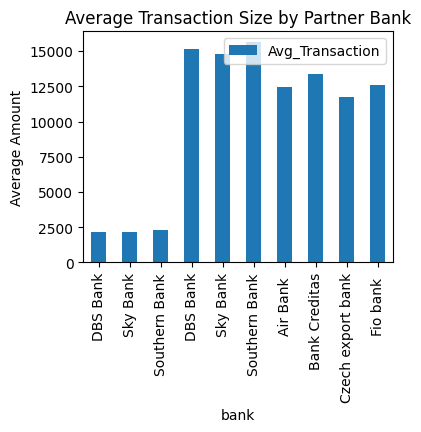

In [234]:
q3.head(10).plot(
    x="bank",
    y="Avg_Transaction",
    kind="bar",
    figsize=(4,3)
)

plt.title("Average Transaction Size by Partner Bank")
plt.ylabel("Average Amount")
plt.show()

In [236]:
print(order_df.columns.tolist())

['order_id', 'account_id', 'Bank_to', 'account_to', 'amount', 'amount_category']


#### Standing Order Category 

In [237]:
q4 = (order_df["amount_category"]
      .value_counts()
      .reset_index())

q4.columns = ["Category", "Count"]

display(q4)

,Category,Count
0,Medium,3682
1,Low,1352
2,High,1300
3,Very High,137


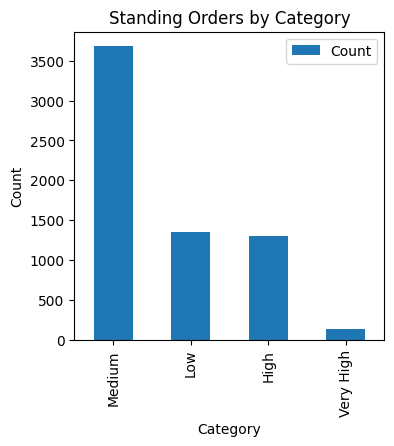

In [240]:
q4.plot(x="Category",
        y="Count",
        kind="bar",
        figsize=(4,4))

plt.title("Standing Orders by Category")
plt.ylabel("Count")
plt.show()

## Part H — Actionable Insights & Recommendations

## 1. Customer Growth & Segmentation
#### Actionable Insights
- The bank has a healthy customer base, but customer distribution is uneven across districts.
- Working-age customers contribute the largest share of banking activity.
- Some regions have significantly lower customer penetration.
#### Recommendations
- Launch targeted acquisition campaigns in low-penetration districts.
- Design products specifically for young professionals and salaried customers.
- Introduce referral programs in underperforming regions.
## 2. Card Business
#### Actionable Insights
- Card adoption is concentrated among specific customer groups.
- Certain card types dominate while others have low adoption.
- Card penetration still has room for improvement.
#### Recommendations
- Cross-sell cards to customers without existing cards.
- Promote premium cards to high-balance customers.
- Offer cashback or reward campaigns to increase card usage.
## 3. Transaction Analysis
#### Actionable Insights
- Most transactions come from a limited number of operation types.
- Some months consistently experience higher transaction volumes.
- A few partner banks handle most transactions.
#### Recommendations
- Allocate infrastructure based on peak transaction periods.
- Improve partnerships with high-volume banks.
- Encourage digital transactions through incentives.
## 4. Loan Portfolio
#### Actionable Insights
- Loan demand varies significantly across customer segments and districts.
- Certain regions contribute higher loan exposure.
- Long-duration loans require closer monitoring.
#### Recommendations
- Focus marketing on districts with high repayment potential.
- Strengthen risk monitoring for large and long-duration loans.
- Develop customized loan products for different customer categories.
## 5. Regional Market Analysis
#### Actionable Insights
- Economic indicators such as salary and population differ significantly across districts.
- Some economically strong districts have relatively low banking penetration.
- Banking activity is concentrated in a few regions.
#### Recommendations
- Expand marketing efforts in economically strong but under-served districts.
- Prioritize branch expansion where population and income are high.
- Tailor regional products based on local demographics.
## 6. Operational Efficiency
#### Actionable Insights
- Standing order categories show different customer payment preferences.
- Statement frequency varies across customer groups.
- Some operational processes can be optimized.
#### Recommendations
- Promote digital standing orders for recurring payments.
- Personalize statement frequency according to customer behavior.
- Automate routine operational workflows to improve efficiency.
## Overall Business Recommendations
- Increase card penetration through targeted cross-selling.
- Expand banking services in high-potential districts.
- Focus loan marketing on low-risk customer segments.
- Encourage digital banking to reduce operational costs.
- Use regional economic indicators for branch planning and marketing decisions.
- Monitor customer behavior regularly using interactive Power BI dashboards.